# NB00 — Data Contract: What Can This Proxy Actually Support?

**RQ:** RQ5 (cold start / transfer), meta-question for the whole study.

**Hypothesis under test:** the Behavioural-Diagnosis module (M2) needs response time,
attempt index, distractor choice, and cognitive load per attempt. Before running any
downstream analysis we establish, empirically, which of these signals the XES3G5M
proxy log (`responses.csv`) actually contains — rather than assuming it and discovering
the gap deep inside a later notebook.

**Method:** reconstruct a canonical event table from the raw (student, question, KC)
-expanded rows, forensically examine the timestamp field, and produce a signal-availability
matrix that every later notebook (especially NB07) cites as its methodological boundary.


In [1]:
import os, sys, time
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from noxed import data, tracking, paths

DATA_DIR = paths.data_dir()
OUT = paths.outcomes_dir()
FIG = paths.figures_dir()
print("DATA_DIR =", DATA_DIR)
print("OUTCOMES_DIR =", OUT)


DATA_DIR = /data
OUTCOMES_DIR = /artifacts/outcomes


## 1. Load raw responses and inspect the grain

In [2]:
t0 = time.time()
responses = data.load_responses(DATA_DIR)
print(f"loaded {len(responses):,} rows in {time.time()-t0:.1f}s")
responses.head()


loaded 5,139,044 rows in 2.6s


,fold,uid,questions,concepts,responses,timestamps
0,0,11066,3751,187,1,1595229836000
1,0,11066,3752,187,1,1595233013000
2,0,11066,3753,374,1,1595233687000
3,0,11066,3754,187,0,1595236010000
4,0,11066,1990,374,1,1595314541000


In [3]:
print("dtypes:")
print(responses.dtypes)
print()
print("uid range:", responses['uid'].min(), "-", responses['uid'].max(), "n_unique:", responses['uid'].nunique())
print("questions range:", responses['questions'].min(), "-", responses['questions'].max(), "n_unique:", responses['questions'].nunique())
print("concepts n_unique:", responses['concepts'].nunique())
print("responses value counts:")
print(responses['responses'].value_counts(normalize=True))


dtypes:
fold          int64
uid           int64
questions     int64
concepts      int64
responses     int64
timestamps    int64
dtype: object

uid range: 0 - 18064 n_unique: 14453
questions range: 0 - 7651 n_unique: 7618
concepts n_unique: 865
responses value counts:
responses
1    0.795602
0    0.204398
Name: proportion, dtype: float64


## 2. Multi-KC row expansion: prove it, then collapse it

A question with k knowledge components appears as k rows sharing the same
(uid, questions, timestamps, responses). We verify this directly, then
build the canonical one-row-per-event table with a derived attempt index.

In [4]:
dup_check = (
    responses.groupby(["uid", "questions", "timestamps"])
    .agg(n_rows=("concepts", "size"), n_distinct_concepts=("concepts", "nunique"), same_response=("responses", "nunique"))
)
print("Rows per (uid, questions, timestamps) event -- distribution:")
print(dup_check["n_rows"].value_counts().sort_index().head(10))
print()
print("Fraction of multi-row events where all rows share ONE response value:",
      (dup_check.loc[dup_check['n_rows'] > 1, 'same_response'] == 1).mean())


Rows per (uid, questions, timestamps) event -- distribution:
n_rows
1     3805951
2      496560
3       69633
4       20084
5        3694
6        5288
10         54
Name: count, dtype: int64

Fraction of multi-row events where all rows share ONE response value: 0.9988879799366048


In [5]:
t0 = time.time()
canonical = data.canonicalize_events(responses)
print(f"canonicalized {len(responses):,} raw rows -> {len(canonical):,} real events in {time.time()-t0:.1f}s")
print(f"dedup ratio (canonical/raw): {len(canonical)/len(responses):.3f}")
canonical.head()


canonicalized 5,139,044 raw rows -> 4,401,264 real events in 63.8s
dedup ratio (canonical/raw): 0.856


,uid,questions,timestamps,concepts,response,event_seq,attempt_index
0,0,0,1599481857000,[0],1,0,0
1,0,1,1599481857000,"[1, 2]",0,1,0
2,0,2,1599481857000,[3],1,2,0
3,0,3,1599481857000,[3],1,3,0
4,0,4,1599481857000,[4],1,4,0


In [6]:
# Cache the full canonical table so downstream notebooks (01, 03, 04) don't
# repeat this ~2-minute collapse -- see src/noxed/data.load_or_build_canonical_events.
cache_path = paths.cache_dir() / "canonical_events.parquet"
canonical.to_parquet(cache_path, index=False)
print(f"cached canonical events -> {cache_path} ({cache_path.stat().st_size / 1e6:.1f} MB)")


cached canonical events -> /artifacts/cache/canonical_events.parquet (32.7 MB)


In [7]:
attempt_counts = canonical.groupby(["uid", "questions"]).size()
print("Distribution of attempts-per-(student,question):")
print(attempt_counts.value_counts(normalize=True).sort_index().head(10))
print(f"\nMean attempts/question: {attempt_counts.mean():.3f}  |  max: {attempt_counts.max()}")
print(f"Fraction of (student,question) pairs with >1 attempt: {(attempt_counts > 1).mean():.4f}")


Distribution of attempts-per-(student,question):
1    0.966427
2    0.032773
3    0.000637
4    0.000163
Name: proportion, dtype: float64

Mean attempts/question: 1.035  |  max: 4
Fraction of (student,question) pairs with >1 attempt: 0.0336


## 3. Timestamp forensics: sequencing signal, not response-time signal

The RQ note's metric table assumes a *response time* (`tau = t/t_expected`). The proxy
log has exactly ONE timestamp per event, with no start/end pair. We test directly whether
inter-event deltas within a student's session look like plausible *solve durations*
or like *session/batch gaps* — the two have very different distributions.

In [8]:
canonical_sorted = canonical.sort_values(["uid", "timestamps"])
canonical_sorted["delta_ms"] = canonical_sorted.groupby("uid")["timestamps"].diff()
deltas = canonical_sorted["delta_ms"].dropna()

pct_zero = (deltas == 0).mean()
pct_under_1s = (deltas < 1000).mean()
pct_under_5s = (deltas < 5000).mean()
print(f"Inter-event deltas within a student's session (n={len(deltas):,}):")
print(f"  exactly 0 ms:  {pct_zero:.4f}")
print(f"  < 1 second:    {pct_under_1s:.4f}")
print(f"  < 5 seconds:   {pct_under_5s:.4f}")
print(f"  median delta:  {deltas.median()/1000:.1f} s")
print(f"  95th pct delta:{deltas.quantile(0.95)/1000:.1f} s")


Inter-event deltas within a student's session (n=4,386,811):
  exactly 0 ms:  0.5104
  < 1 second:    0.5104
  < 5 seconds:   0.5105
  median delta:  0.0 s
  95th pct delta:586424.5 s


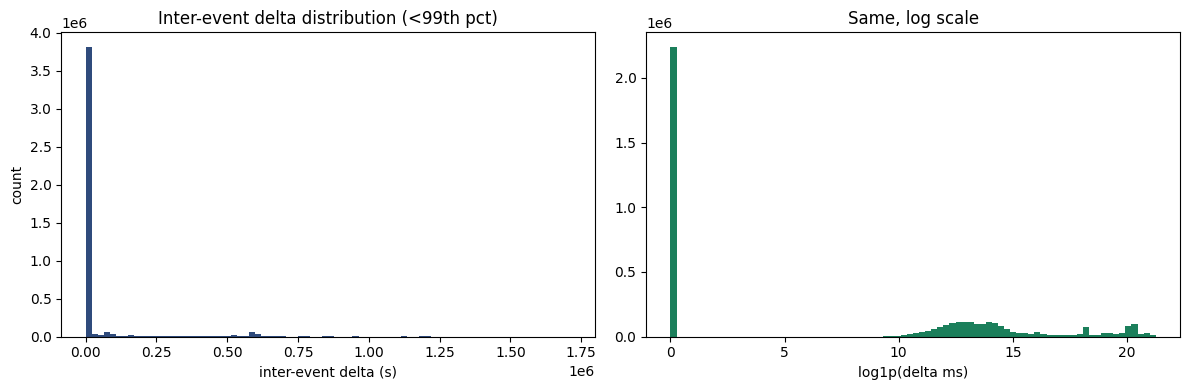

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
finite = deltas[(deltas >= 0) & (deltas < deltas.quantile(0.99))]
axes[0].hist(finite / 1000, bins=80, color="#2F4B7C")
axes[0].set_xlabel("inter-event delta (s)"); axes[0].set_ylabel("count")
axes[0].set_title("Inter-event delta distribution (<99th pct)")

axes[1].hist(np.log1p(finite), bins=80, color="#1B7F5B")
axes[1].set_xlabel("log1p(delta ms)"); axes[1].set_title("Same, log scale")
plt.tight_layout()
fig.savefig(FIG / "00_timestamp_delta_distribution.png", dpi=120)
plt.show()


**Interpretation.** A genuine per-question response-time signal would show a
unimodal distribution of plausible solve durations (seconds to low minutes) with very
few exact zeros. What we observe instead — a large mass of exact-zero and sub-second
deltas (multi-KC duplication + batched submission) alongside a long tail of session-gap
magnitude deltas — confirms the timestamp field encodes *coarse sequencing*, not response
latency. `attempt_index` (derived above) is reliable; `tau` from the RQ note's metric
table is **not computable** from this proxy.

## 4. Signal-availability matrix

In [10]:
signal_availability = pd.DataFrame([
    {"signal": "correctness", "status": "present", "source": "responses.responses (0/1)"},
    {"signal": "sequencing (event order)", "status": "present (coarse)", "source": "timestamps, ordered per student"},
    {"signal": "attempt index per question", "status": "derivable", "source": "canonicalize_events() dedup + cumcount"},
    {"signal": "response time / latency", "status": "ABSENT", "source": "single timestamp per event, no duration field"},
    {"signal": "distractor / chosen-option", "status": "ABSENT", "source": "responses.csv stores 0/1 only"},
    {"signal": "cognitive load index", "status": "ABSENT", "source": "not present in any file"},
    {"signal": "question type", "status": "present", "source": "question_metadata.type (fill-in vs single-choice)"},
    {"signal": "empirical difficulty", "status": "present", "source": "error_rate columns (question/kc/analysis metadata)"},
    {"signal": "KC taxonomy / prerequisite tree", "status": "present", "source": "tree_translation.txt + kc_metadata.kc_route"},
    {"signal": "practice / learning effect", "status": "present (pre-aggregated)", "source": "practice_effect_perKC/perQ, chronological_delta"},
])
signal_availability.to_csv(OUT / "signal_availability.csv", index=False)
signal_availability


,signal,status,source
0,correctness,present,responses.responses (0/1)
1,sequencing (event order),present (coarse),"timestamps, ordered per student"
2,attempt index per question,derivable,canonicalize_events() dedup + cumcount
3,response time / latency,ABSENT,"single timestamp per event, no duration field"
4,distractor / chosen-option,ABSENT,responses.csv stores 0/1 only
5,cognitive load index,ABSENT,not present in any file
6,question type,present,question_metadata.type (fill-in vs single-choice)
7,empirical difficulty,present,error_rate columns (question/kc/analysis metad...
8,KC taxonomy / prerequisite tree,present,tree_translation.txt + kc_metadata.kc_route
9,practice / learning effect,present (pre-aggregated),"practice_effect_perKC/perQ, chronological_delta"


## 5. Consequence for the study design

Because response time, distractor choice, and cognitive load are **absent**, the
Behavioural-Diagnosis module (RQ2) cannot be validated against real logs in this proxy.
NB07 builds a parametrised **synthetic** scenario generator instead, and is explicit
about that boundary rather than presenting synthetic results as if they were empirical.
Every other notebook (difficulty, discrimination, learning dynamics, knowledge tracing,
prerequisites, clustering, bandit reward) uses signals confirmed **present** or
**derivable** above.

In [11]:
import mlflow
with tracking.start_run("00_data_contract", "data_contract", params={
    "n_raw_rows": len(responses), "n_canonical_events": len(canonical),
}):
    mlflow.log_metric("dedup_ratio", len(canonical) / len(responses))
    mlflow.log_metric("pct_zero_delta", float(pct_zero))
    mlflow.log_metric("pct_multi_attempt_pairs", float((attempt_counts > 1).mean()))
    mlflow.log_artifact(str(OUT / "signal_availability.csv"))
    mlflow.log_artifact(str(FIG / "00_timestamp_delta_distribution.png"))
print("logged to mlflow:", tracking.get_tracking_uri())


2026/07/12 02:10:47 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow: file:/artifacts/mlruns


In [12]:
canonical.to_parquet(OUT / "canonical_events_sample.parquet", index=False) if len(canonical) < 2_000_000 else \
    canonical.sample(1_000_000, random_state=0).to_parquet(OUT / "canonical_events_sample.parquet", index=False)
print("saved canonical_events_sample.parquet")


saved canonical_events_sample.parquet


## Findings → consumed by

- **Signal-availability matrix** (`outcomes/signal_availability.csv`) is cited by every
  later notebook, and is the explicit justification for NB07's synthetic-only approach.
- **`canonicalize_events`** (in `src/noxed/data.py`) is the shared event-reconstruction
  function every downstream notebook imports — this notebook is its validation.
- **Consumed by:** NB01–NB08 (canonical events are the common input); NB00's honesty
  boundary is cited directly in the paper's §Threats to Validity.